<a href="https://colab.research.google.com/github/fazmina11/fazmina-codeboosters-2026/blob/main/day2/Day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Copy of student_performance.csv');
print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:", df.head(3))

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:    student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2                     78      Delh

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql('students', conn, if_exists='replace', index=False)
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Database  'college.db' created successfully")
print(f"Table 'students' has {count} rows")

Database  'college.db' created successfully
Table 'students' has 30 rows


In [5]:
cursor.execute("SELECT name,math_score FROM students WHERE math_score > 80  ORDER BY math_score DESC")
rows = cursor.fetchall()
for row in rows[:]:
    print(row)

('Ananya Das', 95)
('Tanvi Mehta', 93)
('Arjun Nair', 92)
('Akanksha Yadav', 91)
('Swati Kulkarni', 90)
('Divya Singh', 88)
('Ritu Agarwal', 87)
('Amit Bose', 86)
('Aarav Sharma', 85)
('Gaurav Shukla', 84)
('Suresh Rao', 83)


In [6]:
# helper function
def run_query(sql, description="student"):
  '''
  Runs a SQL query and returns as a pandas Dataframe.

  Parameters:
  -----------
  sql : str - The SQL query string to execute
  description : str - A label to print above results

  Returns:
  --------
  Pandas Dataframe containing the query results
  '''
  print(f"{'='*65}")
  print(f" {description}")
  print(f"{'='*65}")

  result = pd.read_sql_query(sql, conn)
  print(result.to_string(index=False))
  return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [7]:

query1 = "SELECT student_id, name, department, math_score, attendance_percentage FROM students LIMIT 10"
result1 = run_query(query1, "Query 1: 'SELECT 10 STUDENTS'")

 Query 1: 'SELECT 10 STUDENTS'
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [8]:
query2 = "SELECT name, department, math_score FROM students ORDER BY math_score desc LIMIT 5"
result2 = run_query(query2, "Query 2: 'TOP 5 STUDENTS IN MATH'")

 Query 2: 'TOP 5 STUDENTS IN MATH'
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [9]:

query3 = "SELECT name, math_score, science_score, programming_score, attendance_percentage FROM students WHERE department='Computer Science' ORDER BY math_score desc"
result3 = run_query(query3, "Query 3: COMPUTER STUDENTS (WHERE filter))")
print(f"\nTotal CS students found: {result3.shape[0]}")

 Query 3: COMPUTER STUDENTS (WHERE filter))
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
Swati Kulkarni          90             87                 92                     94
   Divya Singh          88             91                 93                     96
     Amit Bose          86             82                 89                     91
  Aarav Sharma          85             78                 91                     92
 Gaurav Shukla          84             79                 87                     87
    Suresh Rao          83             86                 88                     88
  Nisha Kapoor          79      

In [10]:
query4 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE (attendance_percentage>93 AND department!='Mechanical')
  ORDER BY attendance_percentage desc
  LIMIT 5
"""
result4 = run_query(query4, "Query 4: HIGH ATTENDANCE ABOVE 90% (EXCLUDING CIVIL dept))")

 Query 4: HIGH ATTENDANCE ABOVE 90% (EXCLUDING CIVIL dept))
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94


In [11]:

query5 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE name BETWEEN 'A' AND 'F'
  ORDER BY name
"""
result5 = run_query(query5, "Query 5: STUDENT NAMES FROM 'A' TO 'F'")

 Query 5: STUDENT NAMES FROM 'A' TO 'F'
          name       department  attendance_percentage
  Aarav Sharma Computer Science                     92
   Ajay Tiwari Computer Science                     75
Akanksha Yadav Computer Science                     95
     Amit Bose Computer Science                     91
    Ananya Das Computer Science                     98
    Arjun Nair Computer Science                     90
Deepak Chauhan       Mechanical                     77
   Divya Singh Computer Science                     96


In [12]:
query5 = """
  SELECT department,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math,
  ROUND(AVG(science_score),2) AS avg_science,
  ROUND(AVG(programming_score),2) AS avg_programming,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance
  FROM students
  GROUP BY department
  ORDER BY avg_math desc
"""
result5 = run_query(query5, "Query 5: DEPARTMENT-WISE STUDENT MARKS")

 Query 5: DEPARTMENT-WISE STUDENT MARKS
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [13]:

query6 = """
  SELECT department,
  ROUND(AVG(math_score),2) AS avg_math,
  COUNT(*) AS students
  FROM students
  GROUP BY department
  HAVING avg_math>70
"""
result6 = run_query(query6, "Query 6: DEPARTMENT WITH AVG MATH > 70 (HAVING)")

 Query 6: DEPARTMENT WITH AVG MATH > 70 (HAVING)
      department  avg_math  students
Computer Science     85.62        13
     Electronics     71.00         6
      Mechanical     71.00         6


In [14]:

query7 = """
  SELECT gender,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math,
  ROUND(AVG(programming_score),2) AS avg_programming,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance
  FROM students
  GROUP BY gender
"""
result7 = run_query(query7, "GENDER-WISE PERFORMANCE ANALYSIS")

 GENDER-WISE PERFORMANCE ANALYSIS
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [15]:

query8 = """
  SELECT name, department,
  (math_score+science_score+english_score+programming_score+attendance_percentage) AS tot_score
  FROM students
  ORDER BY tot_score desc
"""
result8 = run_query(query8, "TOTAL SCORE RANKING WITH CALCULATED COLUMN")

 TOTAL SCORE RANKING WITH CALCULATED COLUMN
          name       department  tot_score
    Ananya Das Computer Science        469
   Tanvi Mehta Computer Science        464
Akanksha Yadav Computer Science        460
   Divya Singh Computer Science        452
Swati Kulkarni Computer Science        448
    Arjun Nair Computer Science        446
     Amit Bose Computer Science        427
    Suresh Rao Computer Science        422
  Aarav Sharma Computer Science        418
  Ritu Agarwal      Electronics        418
  Nisha Kapoor Computer Science        416
   Priya Patel Computer Science        412
 Gaurav Shukla Computer Science        412
   Vikram Iyer      Electronics        378
 Kavya Nambiar       Mechanical        376
 Preeti Saxena       Mechanical        373
   Sneha Reddy       Mechanical        368
    Rekha Nair      Electronics        367
   Ajay Tiwari Computer Science        355
    Nitin Jain       Mechanical        355
   Pooja Gupta            Civil        342
   Rohit V

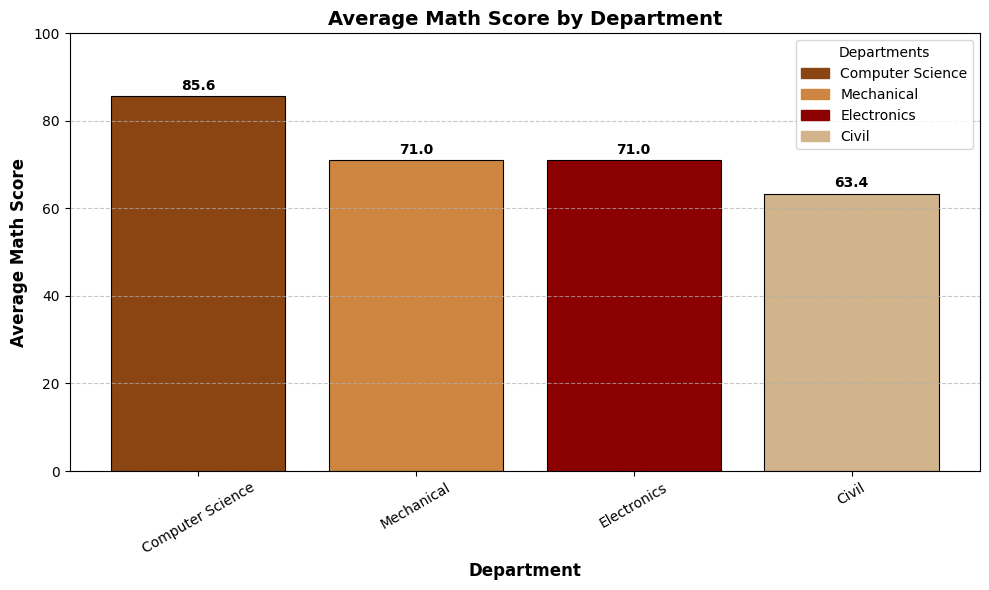

In [16]:

chart1_sql = """
  SELECT department,
         ROUND(AVG(math_score), 2) AS avg_math
  FROM students
  GROUP BY department
  ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colours = ['saddlebrown', 'peru', 'darkred', 'tan', 'wheat']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_math'],
    color=bar_colours[:len(chart1_data)],
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Math Score', fontsize=12, fontweight='bold')
ax.set_title('Average Math Score by Department', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

legend_labels = chart1_data['department'].tolist()
legend_handles = [
    plt.Rectangle((0,0),1,1, color=bar_colours[i], edgecolor='black')
    for i in range(len(legend_labels))
]
ax.legend(legend_handles, legend_labels, title="Departments", loc="upper right")

plt.tight_layout()
plt.show()

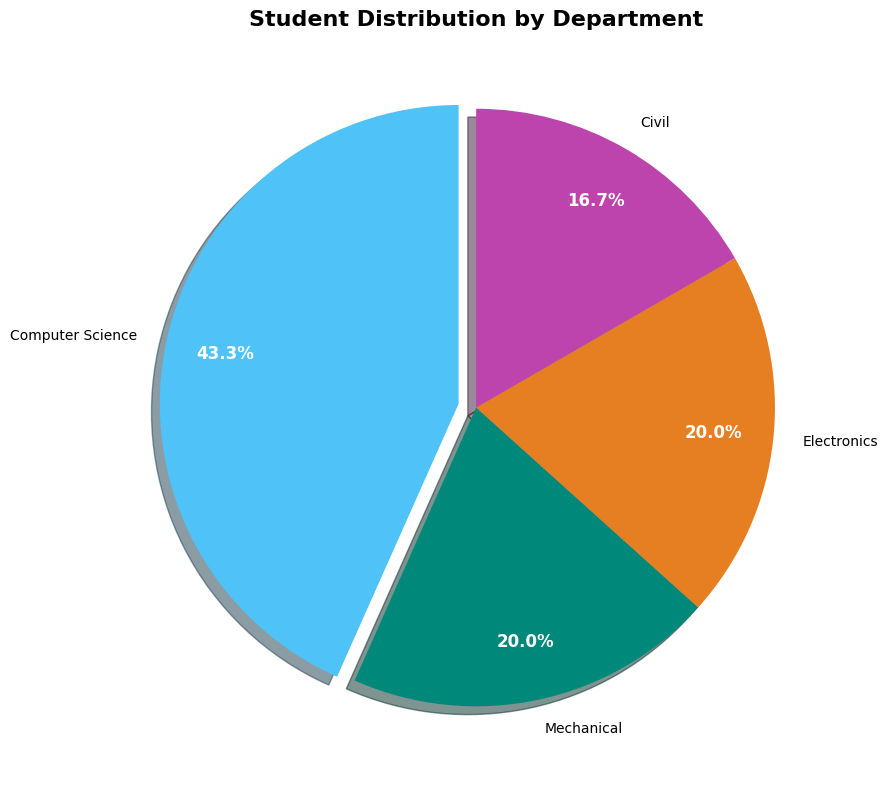


Student count per Department:
      department  num_students
Computer Science            13
      Mechanical             6
     Electronics             6
           Civil             5


In [17]:

chart4_sql = """
  SELECT department, COUNT(*) AS num_students
  FROM students
  GROUP BY department
  ORDER BY num_students DESC
"""

chart4_data = pd.read_sql_query(chart4_sql, conn)

labels = chart4_data['department'].tolist()
sizes = chart4_data['num_students'].tolist()
colors = ['#4FC3F7', '#00897B', '#E67E22', '#BE44AD']
explode = [0.06, 0, 0, 0]

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    shadow=True
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title("Student Distribution by Department", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStudent count per Department:")
print(chart4_data.to_string(index=False))


In [18]:

query9 = """
  SELECT gender,
  AVG(programming_score) AS avg_score
  FROM students
  WHERE gender = 'Female'
  GROUP BY gender
  ORDER BY avg_score DESC;
"""
result9 = run_query(query9, "AVG PROGRAMMING SCORE FOR FEMALE ONLY")

 AVG PROGRAMMING SCORE FOR FEMALE ONLY
gender  avg_score
Female       70.2


In [19]:
query10 = """
  SELECT department,
  ROUND(AVG(attendance_percentage),2) AS avg_percentage
  FROM students
  WHERE attendance_percentage>85
  GROUP BY department
"""
result10 = run_query(query10, "AVG ATTENDANCE PERCENTAGE OF DEPARTMENTS THAT ARE ABOVE 85")

 AVG ATTENDANCE PERCENTAGE OF DEPARTMENTS THAT ARE ABOVE 85
      department  avg_percentage
Computer Science           92.00
     Electronics           93.00
      Mechanical           90.67


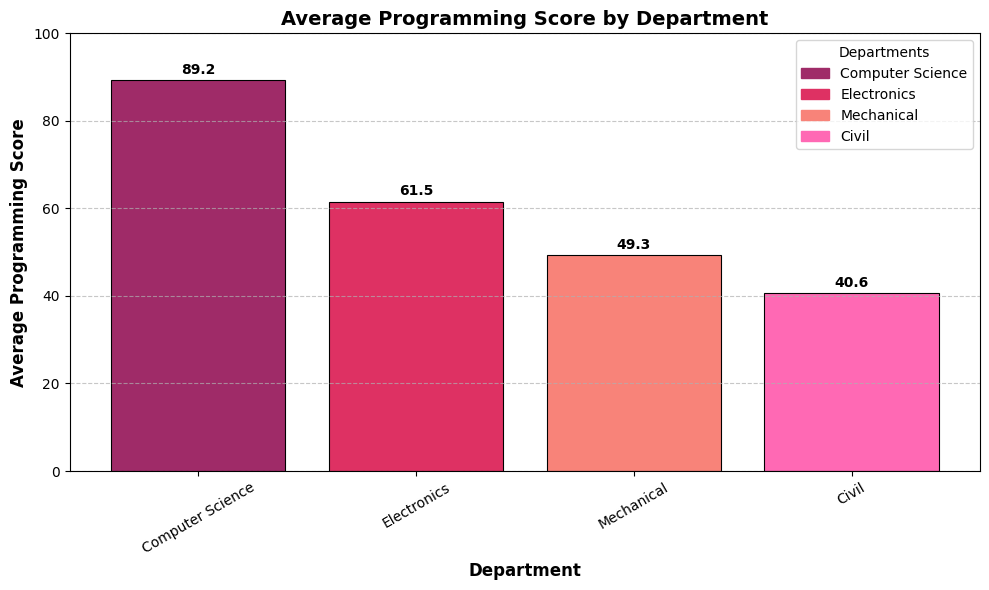

In [20]:

chart1_sql = """
  SELECT department,
  ROUND(AVG(programming_score), 2) AS avg_program
  FROM students
  GROUP BY department
  ORDER BY avg_program DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

bar_colours = ['#9F2B68', '#DE3163', '#F88379', '#FF69B4', '#FFB6C1']

bars = ax.bar(
    chart1_data['department'],
    chart1_data['avg_program'],
    color=bar_colours[:len(chart1_data)],
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

ax.set_xlabel('Department', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Programming Score', fontsize=12, fontweight='bold')
ax.set_title('Average Programming Score by Department', fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', labelsize=10)

legend_labels = chart1_data['department'].tolist()
legend_handles = [
    plt.Rectangle((0,0),1,1, color=bar_colours[i], edgecolor='black')
    for i in range(len(legend_labels))
]
ax.legend(legend_handles, legend_labels, title="Departments", loc="upper right")

plt.tight_layout()
plt.show()